In [88]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
import time
import gymnasium as gym
from datetime import datetime
from pathlib import Path
from pyvirtualdisplay import Display
from scipy import ndimage

import sys, os
sys.path.append(str(Path(os.getcwd()).parent))

from src.e2c import E2CDataset, E2CLoss, E2C
from src.utils import set_seed, anim_frames
from src.eval import Plotter, Evaluator
from src.data_gen.gen_gym import process_image, name_to_env, env_to_aspace

from torchmetrics import PeakSignalNoiseRatio as psnr
from torchmetrics import StructuralSimilarityIndexMeasure as ssim
from tqdm import tqdm

In [81]:
# Parameters
TIME_HORIZON = 8    # How many timesteps to predict into future
yaml_to_load_from = Path(os.getcwd()).parent / "runs/reacher/2025-12-15_12-11-56/config.yaml" # 0.075
yaml_to_load_from = Path(os.getcwd()).parent / "runs/reacher/2025-12-15_11-43-45/config.yaml" # 0.005
yaml_to_load_from = Path(os.getcwd()).parent / "runs/reacher/2025-12-15_11-19-39/config.yaml" # 0.001
yaml_to_load_from = Path(os.getcwd()).parent / "runs/reacher/2025-12-05_15-34-55/config.yaml" # 0.01
yaml_to_load_from = Path(os.getcwd()).parent / "runs/reacher/2025-12-12_12-00-35/config.yaml" # 0.1
yaml_to_load_from = Path(os.getcwd()).parent / "runs/reacher/2025-12-12_17-03-59/config.yaml" # 0.2
model_checkpoint = yaml_to_load_from.parent / "model.pt"
with open(yaml_to_load_from, "r") as f:
    config = yaml.safe_load(f)
device = torch.device(config['train']['device'])
if 'cuda' in config['train']['device']: 
    assert torch.cuda.is_available(), f"{config['train']['device']} selected in config, but is unavailable!"
# Load model
config['vae']['out_image_shape'] = (9, 64, 64)
config['trans']['control_size'] = (2)
model = E2C(
    enc_latent_size=config['vae']['enc_latent_size'],
    latent_size=config['trans']['latent_size'],
    control_size=config['trans']['control_size'],
    past_length=config['trans']['past_length'],
    pred_length=config['trans']['pred_length'],
    conv_params=config['vae'],
    device=device
)
model.to(device)
state_dict = torch.load(model_checkpoint, map_location=device)
model.load_state_dict(state_dict)
model.eval()
print("Model loaded.")

Model loaded.


In [82]:
# Create virtual display for running on server
disp = Display(visible=0, size=(480, 480))
disp.start()

In [83]:
mj_path = Path(os.path.dirname(gym.__file__)) / "envs" / "mujoco" / "assets" # mujoco path
num_ms = config['train']['dataset']
if num_ms.__contains__('/'):
    num_ms = num_ms.split('_')[1].split('ms')[0]
num_ms = 7 if num_ms == '7dot5' else num_ms
new_xml_filename = f"reacher_timestep_{num_ms}_ms.xml"
if num_ms == 'reacher':
    env = gym.make(name_to_env[config['train']['dataset']], render_mode="rgb_array")
else:
    env = gym.make(name_to_env[config['train']['dataset'].split('/')[0]], render_mode="rgb_array", xml_file=new_xml_filename)

torch.Size([1, 64, 64, 3]) torch.Size([1, 64, 64, 3]) torch.Size([1, 64, 64, 3])
torch.Size([1, 64, 64, 3]) torch.Size([1, 64, 64, 3]) torch.Size([1, 64, 64, 3])
torch.Size([1, 64, 64, 3]) torch.Size([1, 64, 64, 3]) torch.Size([1, 64, 64, 3])
torch.Size([1, 64, 64, 3]) torch.Size([1, 64, 64, 3]) torch.Size([1, 64, 64, 3])
torch.Size([1, 64, 64, 3]) torch.Size([1, 64, 64, 3]) torch.Size([1, 64, 64, 3])
torch.Size([1, 64, 64, 3]) torch.Size([1, 64, 64, 3]) torch.Size([1, 64, 64, 3])
Open Loop Metrics:
PSNR: 25.4642, [28.999357223510742, 27.007902145385742, 25.96575355529785, 27.678184509277344, 21.59427833557129, 21.539592742919922]
SSIM: nan, []
One Step Metrics:
PSNR: 28.6473, [28.926687240600586, 28.86746597290039, 28.3171329498291, 28.745464324951172, 28.433395385742188, 28.593387603759766]
SSIM: nan, []


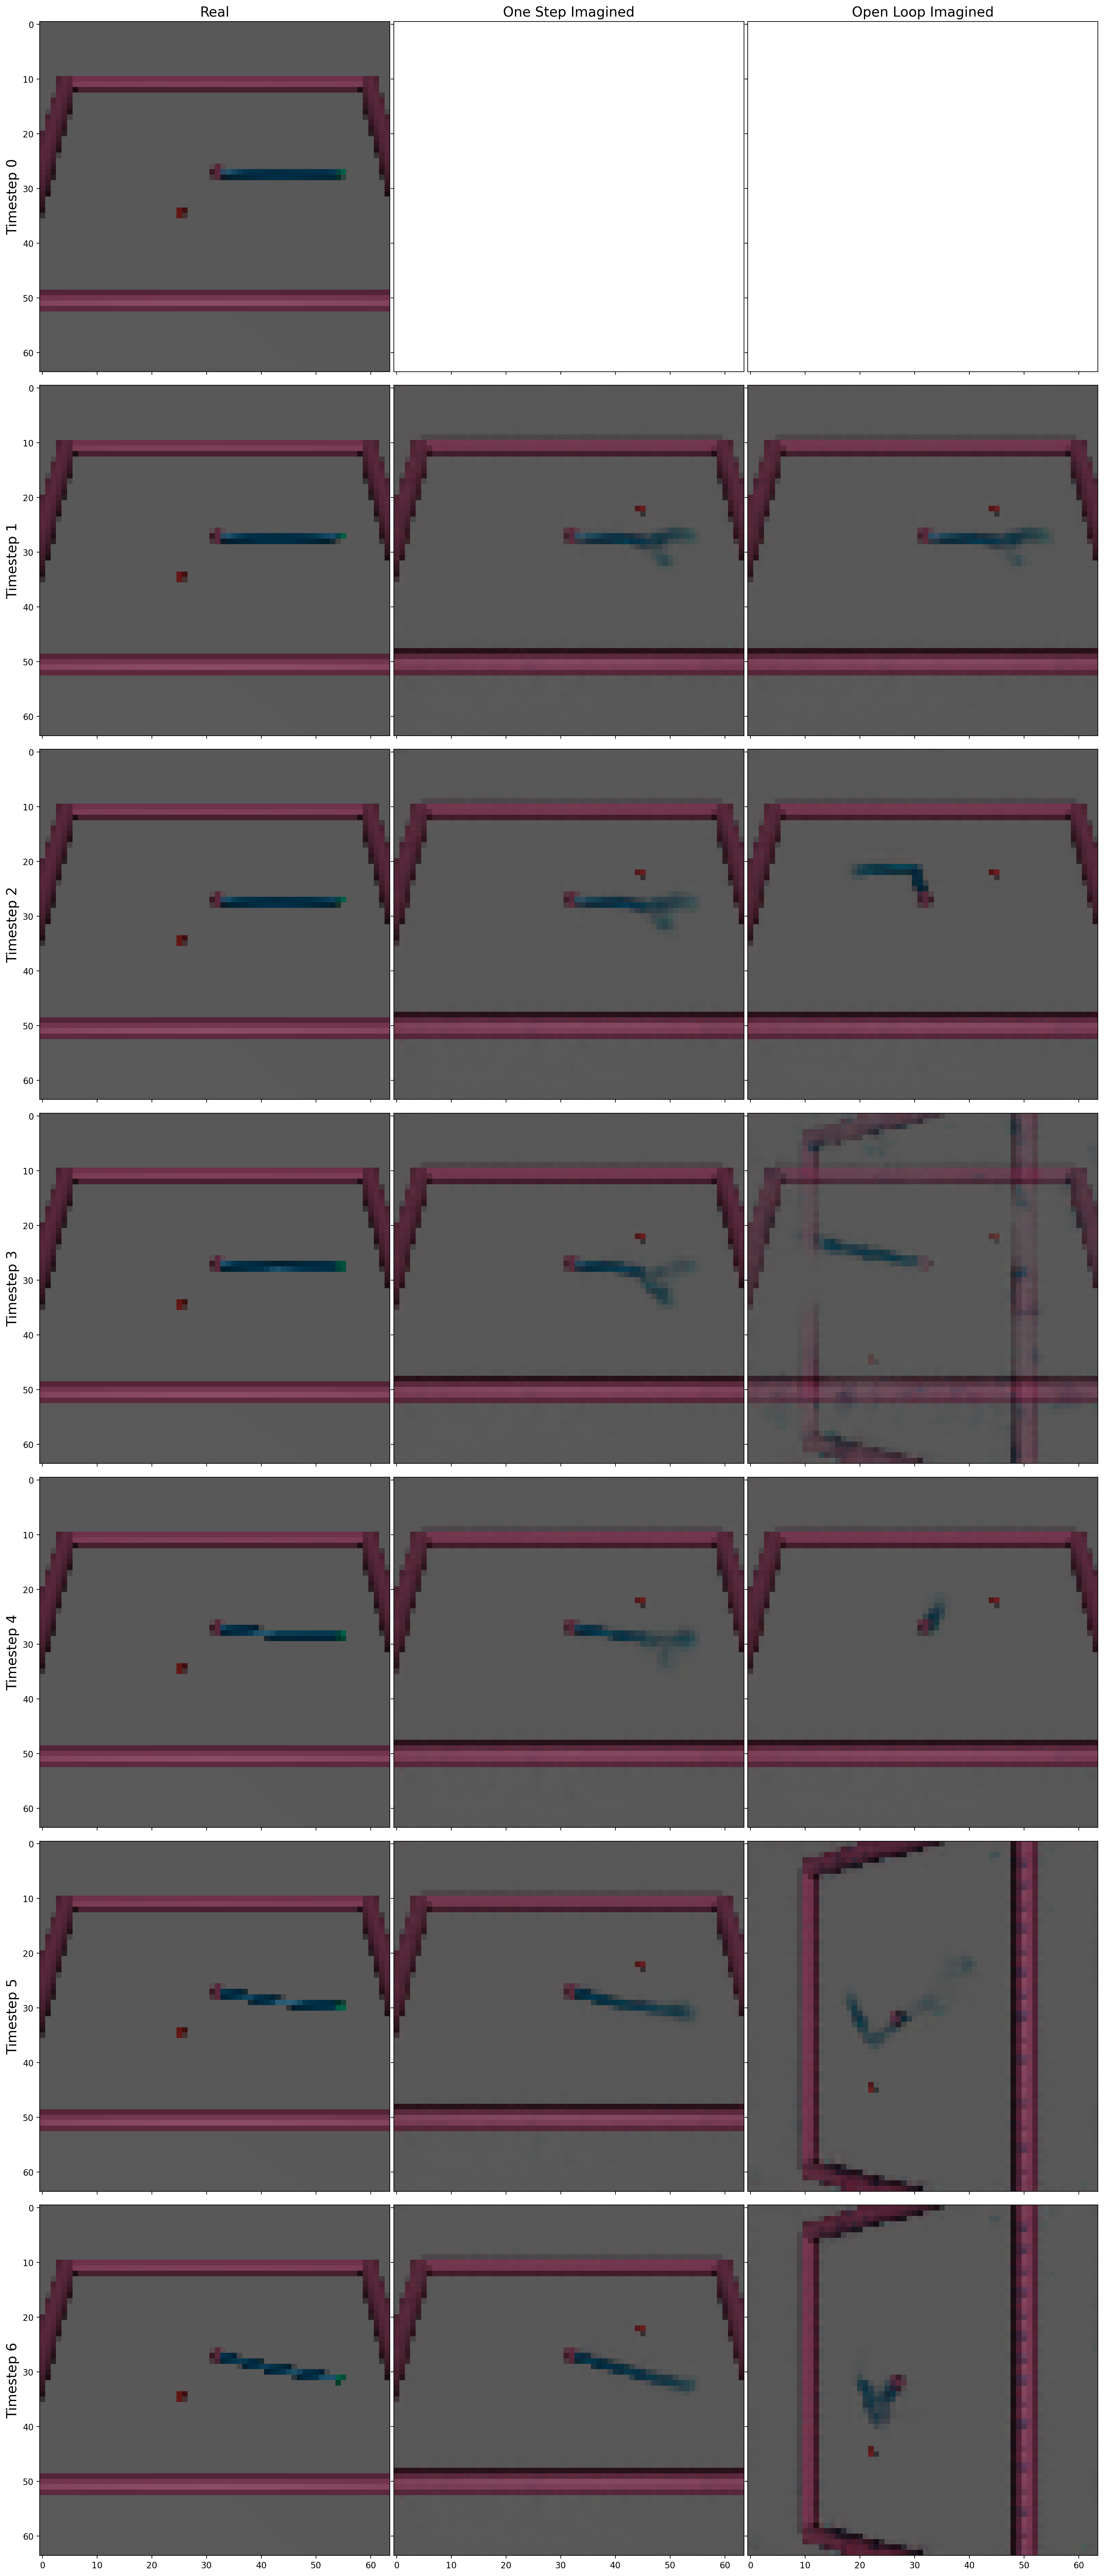

In [ ]:
open_loop_metrics = {'psnr': [], 'ssim': [], 'lpips': []}
one_step_metrics = {'psnr': [], 'ssim': [], 'lpips': []}
psnr_fn = psnr(data_range=1.0).to(device)
ssim_fn = ssim(data_range=1.0).to(device)

TIME_HORIZON = 6
seed_to_set = 12
fig, axes = plt.subplots(TIME_HORIZON + 1, 3, figsize=(18, TIME_HORIZON*7), dpi=200, tight_layout=True, sharey=True, sharex=True)
for ax in axes.flatten():
    # ax.axis('off')
    ax.set_aspect('equal')
fontsize = 16
axes[0, 0].set_title('Real', fontsize=fontsize)
axes[0, 1].set_title('One Step Imagined', fontsize=fontsize)
axes[0, 2].set_title('Open Loop Imagined', fontsize=fontsize)
for row in range(TIME_HORIZON + 1):
    axes[row, 0].set_ylabel(f'Timestep {row}', fontsize=fontsize)

obs, _ = env.reset(seed=seed_to_set)
img = env.render()
# generate buffer of past images
img_source = torch.zeros((config['trans']['past_length'], *(3, 64, 64)), device=device)
for i in range(config['trans']['past_length']):
    action = env.action_space.sample()
    # action[0] = -0.2 # Consistent action for reproducibility
    # action[1] = -0.2 # movement of second joint
    obs, reward, done, truncated, info = env.step(action)
    img = env.render()
    img_source[i] = process_image(img, 'reacher').squeeze().permute(2, 0, 1).to(device)

axes[0, 0].imshow(process_image(img, 'reacher').squeeze())

all_controls = torch.zeros((TIME_HORIZON, config['trans']['control_size']), device=device)
all_zs = torch.zeros((TIME_HORIZON, model.latent_size), device=device)
all_mus = torch.zeros((TIME_HORIZON, model.latent_size), device=device)
all_logvars = torch.zeros((TIME_HORIZON, model.latent_size), device=device)
for i in range(1, TIME_HORIZON+1):
    action = env.action_space.sample()
    # action[0] = -0.2 # Consistent action for reproducibility
    # action[1] = -0.2 # No movement of second joint
    all_controls[i-1] = torch.tensor(action, device=device)
    obs, reward, done, truncated, info = env.step(action)
    img = env.render()
    axes[i, 0].imshow(process_image(img, 'reacher').squeeze(0))
    gt = process_image(img, 'reacher')

    # move image buffer
    for j in range(config['trans']['past_length'] - 1):
        img_source[j] = img_source[j + 1]
    img_source[-1] = process_image(img, 'reacher').squeeze().permute(2, 0, 1).to(device)

    # Prepare inputs for model
    x = img_source.unsqueeze(0)  # (1, past_length, C, H, W)
    x = x.reshape(x.shape[0], -1, *config['vae']['out_image_shape'][1:])  # (1, past_length, C, H, W) -> (1, past_length*C, H, W)
    u = all_controls[i-1].unsqueeze(0)  # (1, control_size)
    with torch.no_grad():
        enc_out = model.encoder(x)
        mu_0, logvar_0 = model.mu(enc_out), model.log_var(enc_out)
        z_0 = model.reparameterize(mu_0, logvar_0)
        if i == 1:
            all_zs[0] = z_0.squeeze()
            all_mus[0] = mu_0.squeeze()
            all_logvars[0] = logvar_0.squeeze()
        
        # One step prediction
        _, _, z_next_hat, _, _ = model.transition(z_0, mu_0, logvar_0, u)
        one_step = model.decoder(z_next_hat)
        one_step = one_step.cpu()[0, :3].permute(2, 1, 0).unsqueeze(0)
        axes[i, 1].imshow(one_step.numpy().squeeze(0))

        # Open loop prediction
        mu_pred, log_var_pred, z_next_hat, _, _ = model.transition(all_zs[i-1].unsqueeze(0), all_mus[i-1].unsqueeze(0), all_logvars[i-1].unsqueeze(0), u)
        # mu_pred, log_var_pred, z_next_hat, _, _ = model.transition(all_zs[i-1].unsqueeze(0), mu_0, logvar_0, u)
        open_loop = model.decoder(z_next_hat)
        open_loop = open_loop.cpu()[0, :3].permute(2, 1, 0).unsqueeze(0)
        axes[i, 2].imshow(open_loop.squeeze(0).numpy())
        if i <= TIME_HORIZON:
            all_zs[i-1] = z_next_hat.squeeze()
            all_mus[i-1] = mu_pred.squeeze()
            all_logvars[i-1] = log_var_pred.squeeze()

        # Compute metrics
        print(open_loop.shape, gt.shape, one_step.shape)
        open_loop_metrics['psnr'].append(psnr_fn(open_loop, gt).item())
        # open_loop_metrics['ssim'].append(ssim_fn(open_loop, gt).item())
        one_step_metrics['psnr'].append(psnr_fn(one_step, gt).item())
        # one_step_metrics['ssim'].append(ssim_fn(one_step, gt).item())


print('Open Loop Metrics:')
print(f"PSNR: {np.mean(open_loop_metrics['psnr']):.4f}, {open_loop_metrics['psnr']}")
# print(f"SSIM: {np.mean(open_loop_metrics['ssim']):.4f}, {open_loop_metrics['ssim']}")

print('One Step Metrics:')
print(f"PSNR: {np.mean(one_step_metrics['psnr']):.4f}, {one_step_metrics['psnr']}")
# print(f"SSIM: {np.mean(one_step_metrics['ssim']):.4f}, {one_step_metrics['ssim']}")
plt.show()


In [97]:
def rollout(env, model, seed_to_set):
    """
    Run a single rollout and return metrics.
    
    initial_state: numpy array, initial env state
    control_seq: torch tensor of shape (TIME_HORIZON, control_size)
    """
    obs, _ = env.reset(seed=seed_to_set)
    img = env.render()
    # generate buffer of past images
    img_source = torch.zeros((config['trans']['past_length'], *(3, 64, 64)), device=device)
    for i in range(config['trans']['past_length']):
        action = env.action_space.sample()
        action[0] = -0.2 # Consistent action for reproducibility
        action[1] = -0.2 # movement of second joint
        obs, reward, done, truncated, info = env.step(action)
        img = env.render()
        img_source[i] = process_image(img, 'reacher').squeeze().permute(2, 0, 1).to(device)

    # axes[0, 0].imshow(process_image(img, 'reacher').squeeze())

    all_controls = torch.zeros((TIME_HORIZON, config['trans']['control_size']), device=device)
    all_zs = torch.zeros((TIME_HORIZON, model.latent_size), device=device)
    all_mus = torch.zeros((TIME_HORIZON, model.latent_size), device=device)
    all_logvars = torch.zeros((TIME_HORIZON, model.latent_size), device=device)
    for i in range(1, TIME_HORIZON+1):
        action = env.action_space.sample()
        action[0] = -0.2 # Consistent action for reproducibility
        action[1] = -0.2 # No movement of second joint
        all_controls[i-1] = torch.tensor(action, device=device)
        obs, reward, done, truncated, info = env.step(action)
        img = env.render()
        # axes[i, 0].imshow(process_image(img, 'reacher').squeeze(0))
        gt = process_image(img, 'reacher')

        # move image buffer
        for j in range(config['trans']['past_length'] - 1):
            img_source[j] = img_source[j + 1]
        img_source[-1] = process_image(img, 'reacher').squeeze().permute(2, 0, 1).to(device)

        # Prepare inputs for model
        x = img_source.unsqueeze(0)  # (1, past_length, C, H, W)
        x = x.reshape(x.shape[0], -1, *config['vae']['out_image_shape'][1:])  # (1, past_length, C, H, W) -> (1, past_length*C, H, W)
        u = all_controls[i-1].unsqueeze(0)  # (1, control_size)
        with torch.no_grad():
            enc_out = model.encoder(x)
            mu_0, logvar_0 = model.mu(enc_out), model.log_var(enc_out)
            z_0 = model.reparameterize(mu_0, logvar_0)
            if i == 1:
                all_zs[0] = z_0.squeeze()
                all_mus[0] = mu_0.squeeze()
                all_logvars[0] = logvar_0.squeeze()
            
            # One step prediction
            _, _, z_next_hat, _, _ = model.transition(z_0, mu_0, logvar_0, u)
            one_step = model.decoder(z_next_hat)
            one_step = one_step.cpu()[0, :3].permute(2, 1, 0).unsqueeze(0)
            # axes[i, 1].imshow(one_step.numpy().squeeze(0))

            # Open loop prediction
            mu_pred, log_var_pred, z_next_hat, _, _ = model.transition(all_zs[i-1].unsqueeze(0), all_mus[i-1].unsqueeze(0), all_logvars[i-1].unsqueeze(0), u)
            # mu_pred, log_var_pred, z_next_hat, _, _ = model.transition(all_zs[i-1].unsqueeze(0), mu_0, logvar_0, u)
            open_loop = model.decoder(z_next_hat)
            open_loop = open_loop.cpu()[0, :3].permute(2, 1, 0).unsqueeze(0)
            # axes[i, 2].imshow(open_loop.squeeze(0).numpy())
            if i <= TIME_HORIZON:
                all_zs[i-1] = z_next_hat.squeeze()
                all_mus[i-1] = mu_pred.squeeze()
                all_logvars[i-1] = log_var_pred.squeeze()

            # Compute metrics
            # print(open_loop.shape, gt.shape, one_step.shape)
            open_loop_metrics['psnr'].append(psnr_fn(open_loop, gt).item())
            # open_loop_metrics['ssim'].append(ssim_fn(open_loop, gt).item())
            one_step_metrics['psnr'].append(psnr_fn(one_step, gt).item())
            # one_step_metrics['ssim'].append(ssim_fn(one_step, gt).item())
    
    return open_loop_metrics, one_step_metrics

In [98]:
# Parameters
TIME_HORIZON = 8    # How many timesteps to predict into future
all_yamls = [
    Path(os.getcwd()).parent / "runs/reacher/2025-12-15_12-11-56/config.yaml", # 0.075
    Path(os.getcwd()).parent / "runs/reacher/2025-12-15_11-43-45/config.yaml", # 0.005
    Path(os.getcwd()).parent / "runs/reacher/2025-12-15_11-19-39/config.yaml", # 0.001
    Path(os.getcwd()).parent / "runs/reacher/2025-12-05_15-34-55/config.yaml", # 0.01
    Path(os.getcwd()).parent / "runs/reacher/2025-12-12_12-00-35/config.yaml", # 0.1
    Path(os.getcwd()).parent / "runs/reacher/2025-12-12_17-03-59/config.yaml", # 0.2
]

for yaml_to_load_from in tqdm(all_yamls):
    with open(yaml_to_load_from, "r") as f:
        config = yaml.safe_load(f)
    device = torch.device(config['train']['device'])
    if 'cuda' in config['train']['device']: 
        assert torch.cuda.is_available(), f"{config['train']['device']} selected in config, but is unavailable!"
    # Load model
    config['vae']['out_image_shape'] = (9, 64, 64)
    config['trans']['control_size'] = (2)
    model = E2C(
        enc_latent_size=config['vae']['enc_latent_size'],
        latent_size=config['trans']['latent_size'],
        control_size=config['trans']['control_size'],
        past_length=config['trans']['past_length'],
        pred_length=config['trans']['pred_length'],
        conv_params=config['vae'],
        device=device
    )
    model.to(device)
    state_dict = torch.load(model_checkpoint, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()

    mj_path = Path(os.path.dirname(gym.__file__)) / "envs" / "mujoco" / "assets" # mujoco path
    num_ms = config['train']['dataset']
    if num_ms.__contains__('/'):
        num_ms = num_ms.split('_')[1].split('ms')[0]
    num_ms = 7 if num_ms == '7dot5' else num_ms
    new_xml_filename = f"reacher_timestep_{num_ms}_ms.xml"
    if num_ms == 'reacher':
        env = gym.make(name_to_env[config['train']['dataset']], render_mode="rgb_array")
    else:
        env = gym.make(name_to_env[config['train']['dataset'].split('/')[0]], render_mode="rgb_array", xml_file=new_xml_filename)

    print("Model:", num_ms, "ms", new_xml_filename)
    all_open_loop_psnr = []
    all_one_step_psnr = []

    for n in range(50):
        ol_metrics, os_metrics = rollout(env, model, n)
        all_open_loop_psnr.append(np.mean(ol_metrics['psnr']))
        all_one_step_psnr.append(np.mean(os_metrics['psnr']))

    print("Open-loop PSNR:", np.mean(all_open_loop_psnr)) #, all_open_loop_psnr)
    print("One-step PSNR:", np.mean(all_one_step_psnr)) #, all_one_step_psnr)
    print()


  0%|          | 0/6 [00:00<?, ?it/s]

Model: 7 ms reacher_timestep_7_ms.xml


 17%|█▋        | 1/6 [00:04<00:20,  4.10s/it]

Open-loop PSNR: 26.73344902079756
One-step PSNR: 27.88640350268768

Model: 5 ms reacher_timestep_5_ms.xml


 33%|███▎      | 2/6 [00:08<00:16,  4.06s/it]

...

Open-loop PSNR: 26.715344224104456
One-step PSNR: 27.84785737490795

Model: 100 ms reacher_timestep_100_ms.xml


 83%|████████▎ | 5/6 [00:20<00:04,  4.16s/it]

Open-loop PSNR: 26.717375641430426
One-step PSNR: 27.844214967097113

Model: 200 ms reacher_timestep_200_ms.xml


100%|██████████| 6/6 [00:24<00:00,  4.14s/it]

Open-loop PSNR: 26.726907267500266
One-step PSNR: 27.84820397906825



- 0.001:
    Open-loop PSNR: 26.516046055398654
    One-step PSNR: 29.18237466963547

- 0.005:
    Open-loop PSNR: 26.069194712122613
    One-step PSNR: 28.476529898183607
    
- 0.0075:
    Open-loop PSNR: 26.052333714636905
    One-step PSNR: 28.669477532610237

- 0.01:
    Open-loop PSNR: 26.939564992462
    One-step PSNR: 30.012008525920926

- 0.1:
    Open-loop PSNR: 27.181635015366663
    One-step PSNR: 30.240782109268263

- 0.2:
    Open-loop PSNR: 27.234285196907898
    One-step PSNR: 30.07342492869547